In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from helper.algorithms import ClassificationAlgorithms
# joblib for seving the model
import joblib

In [2]:

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [3]:
df = pd.read_pickle("../processed_data/modelData.pkl")
df = df.drop("epoch (ms)", axis=1)

In [4]:
df_train = df.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

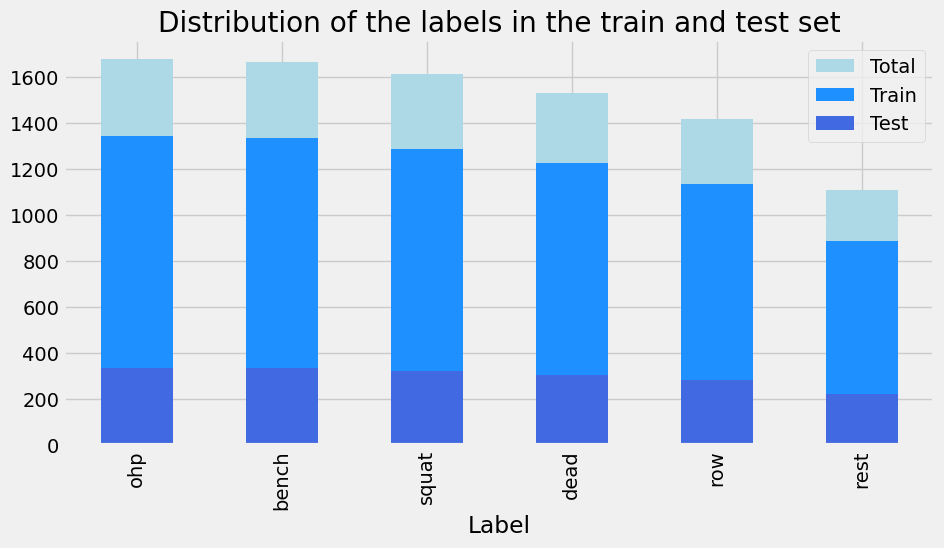

In [ ]:
# create a plot
fig, ax = plt.subplots(figsize=(10, 5))
df_train["Label"].value_counts().plot(
    kind="bar", ax=ax, color = "lightgreen", label="Total"
   )
y_train.value_counts().plot(kind="bar", ax=ax, color = "dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color = "royalblue", label="Test")
plt.legend()
plt.title("Distribution of the labels in the train and test set")
plt.show()


In [6]:
df.columns

Index(['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z', 'Gyroscope_x',
       'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label', 'Category',
       'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r', 'Gyroscope_r',
       'Accelerometer_x_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5',
       'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_x_temp_mean_ws_5',
       'Gyroscope_y_temp_mean_ws_5', 'Gyroscope_z_temp_mean_ws_5',
       'Accelerometer_r_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5',
       'cluster_acc', 'cluster_gyro'],
      dtype='object')

In [7]:
# split the features 
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))


Basic features:  6
Squere features:  2
PCA features:  3
Cluster features:  2


In [8]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + pca_feactures))
feature_set_4 = list(set(feature_set_3 + cluster_feactures))

In [9]:
# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

Starting forward selection...
Selecting feature 1/10...
After selecting feature 1/10, selected features: ['pca_1']
Selecting feature 2/10...
After selecting feature 2/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5']
Selecting feature 3/10...
After selecting feature 3/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5', 'pca_2']
Selecting feature 4/10...
After selecting feature 4/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5', 'pca_2', 'Accelerometer_x']
Selecting feature 5/10...
After selecting feature 5/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5', 'pca_2', 'Accelerometer_x', 'Accelerometer_x_temp_mean_ws_5']
Selecting feature 6/10...
After selecting feature 6/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5', 'pca_2', 'Accelerometer_x', 'Accelerometer_x_temp_mean_ws_5', 'Gyroscope_z']
Selecting feature 7/10...
After selecting feature 7/10, selected features: ['pca_1', 'Gyroscope_r_temp_mean_ws_5', 'pca_2', 'Accelerom

Text(0.5, 1.0, 'Forward selection')

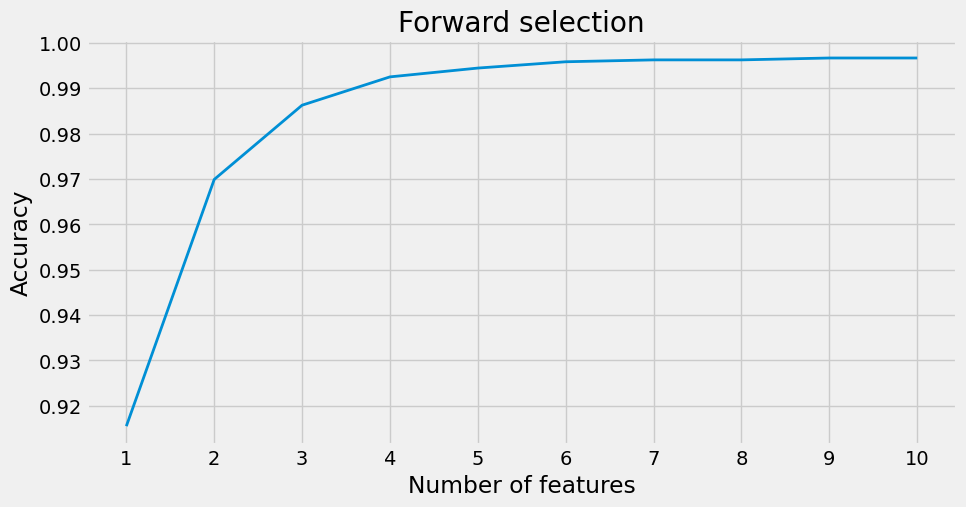

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")


In [11]:
# feature sets
possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, selected_features]
feature_names = ["Feature Set 1", "Feature Set 2", "Feature Set 3", "Feature Set 4", "Selected features"]

iterations = 1
score_df = pd.DataFrame()

# iterate over feature sets
for i, f in enumerate(feature_names):
    print(feature_names[i])
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # Random Forest
    print("\tTraining random forest")
    performance_test_rf = sum(
        accuracy_score(y_test, learner.random_forest(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])
        for _ in range(iterations)
    ) / iterations

    # KNN
    print("\tTraining KNN")
    performance_test_knn = accuracy_score(y_test, learner.k_nearest_neighbor(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Decision Tree
    print("\tTraining decision tree")
    performance_test_dt = accuracy_score(y_test, learner.decision_tree(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Naive Bayes
    print("\tTraining naive bayes")
    performance_test_nb = accuracy_score(y_test, learner.naive_bayes(selected_train_X, y_train, selected_test_X)[1])

    # SVM without kernel
    print("\tTraining SVM without kernel")
    performance_test_svm_no_kernel = accuracy_score(y_test, learner.svm_without_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # SVM with kernel
    #print("\tTraining SVM with kernel")
    #performance_test_svm_kernel = accuracy_score(y_test, learner.svm_with_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Logistic Regression
    print("\tTraining logistic regression")
    performance_test_logistic = accuracy_score(y_test, learner.logistic_regression(selected_train_X, y_train, selected_test_X)[1])

    # Save results to dataframe
    new_scores = pd.DataFrame({
        "model": ["RF", "KNN", "DT", "NB", "SVM-No-Kernel", "Logistic-Regression"], # can add SVM with kernel
        "feature_set": f,
        "accuracy": [performance_test_rf, performance_test_knn, performance_test_dt, performance_test_nb, performance_test_svm_no_kernel, performance_test_logistic], # performance_test_svm_kernel
    })
    
    score_df = pd.concat([score_df, new_scores], ignore_index=True)


Feature Set 1
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 2
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 3
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 4
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Selected features
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression


In [12]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
24,RF,Selected features,0.980577
12,RF,Feature Set 3,0.966704
18,RF,Feature Set 4,0.966704
26,DT,Selected features,0.965039
0,RF,Feature Set 1,0.964484
6,RF,Feature Set 2,0.963374
2,DT,Feature Set 1,0.942286
14,DT,Feature Set 3,0.940622
8,DT,Feature Set 2,0.940622
20,DT,Feature Set 4,0.938957


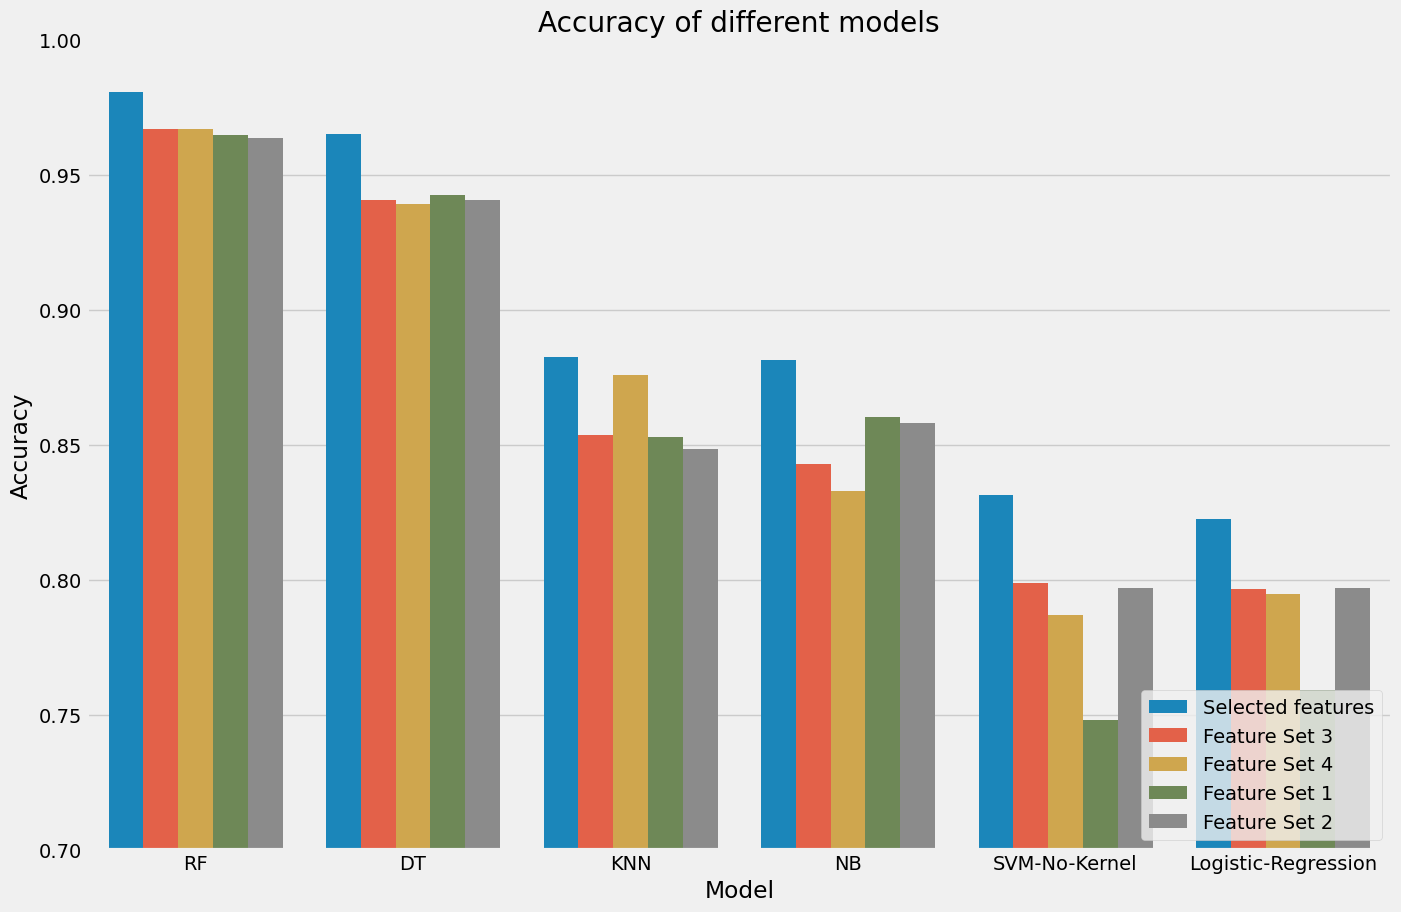

In [13]:
plt.figure(figsize=(15, 10))
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df)
plt.title("Accuracy of different models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.legend(loc="lower right")
plt.show()

In [27]:
# random forest
pred_train, pred_test, = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, pred_test, labels=y.unique())
cm

array([[318,  15,   0,   0,   0,   0],
       [ 15, 320,   0,   0,   0,   0],
       [  0,   2, 319,   0,   0,   1],
       [  0,   0,   0, 304,   2,   0],
       [  0,   0,   0,   0, 283,   1],
       [  0,   0,   0,   0,   0, 222]])

In [17]:
# print accurrency on test set
accuracy_score(y_test, pred_test)

0.9800221975582686

In [18]:
report = classification_report(y_test, pred_test, labels=y.unique(), output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
bench,0.954955,0.954955,0.954955,333.000000
ohp,0.949555,0.955224,0.952381,335.000000
squat,1.000000,0.990683,0.995320,322.000000
dead,1.000000,0.993464,0.996721,306.000000
row,0.992982,0.996479,0.994728,284.000000
rest,0.991071,1.000000,0.995516,222.000000
accuracy,0.980022,0.980022,0.980022,0.980022
macro avg,0.981427,0.981801,0.981603,1802.000000
weighted avg,0.980092,0.980022,0.980047,1802.000000


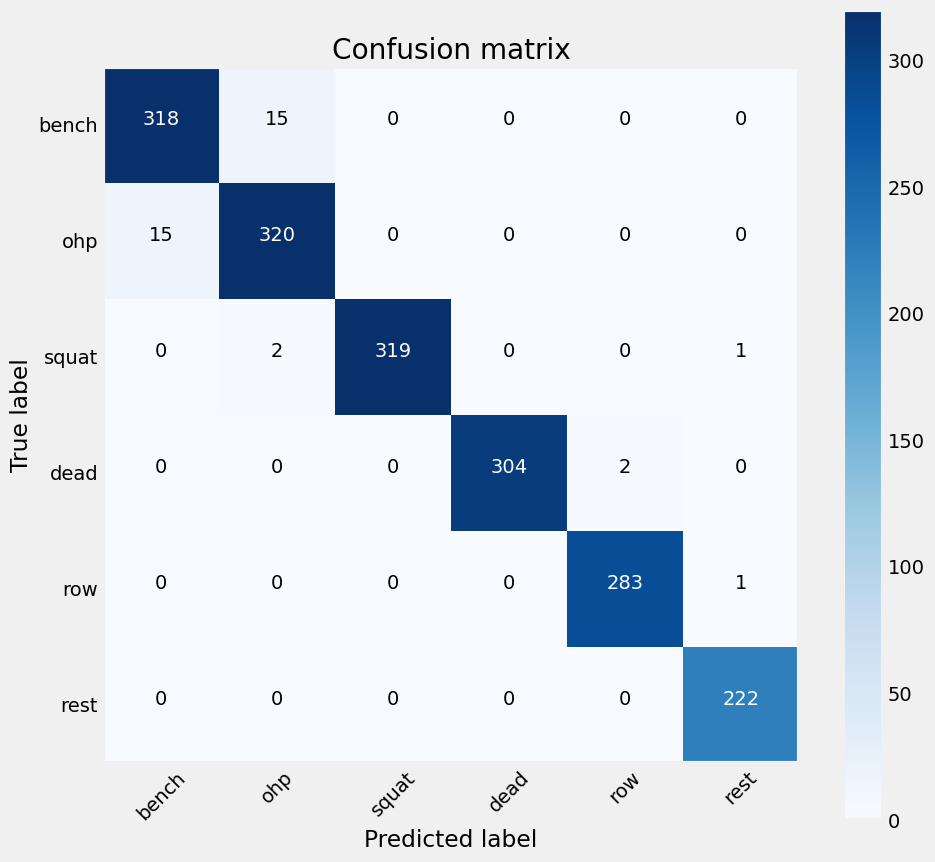

In [19]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

## Check overfitting

In [20]:
# trying the model for overfitting seeing how it proforms on the training set
#pred_train, pred_test, = learner.random_forest(X_train[feature_set_2], y_train, X_train[feature_set_2], gridsearch=True)
cm = confusion_matrix(y_train, pred_train, labels=y.unique())
cm

array([[1327,    5,    0,    0,    0,    0],
       [   3, 1338,    0,    0,    0,    0],
       [   0,    0, 1288,    0,    0,    0],
       [   0,    0,    0, 1225,    0,    0],
       [   0,    0,    0,    0, 1133,    0],
       [   0,    0,    0,    0,    0,  888]])

In [21]:
# perint accuracy
accuracy_score(y_train, pred_train)

0.9988899680865825

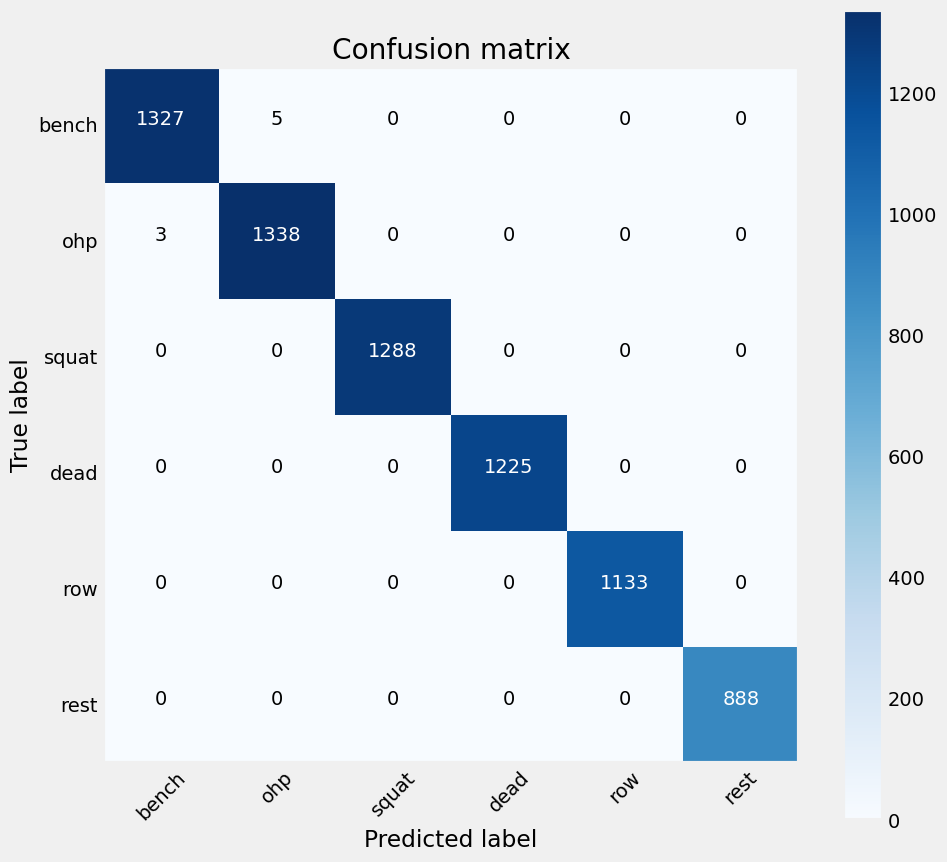

In [22]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

In [24]:
model = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

In [25]:
# save the model
joblib.dump(model, '../model/random_forest_model.pkl')


['../model/random_forest_model.pkl']